## German to English Translation Guide

This notebook analyzes Swiss cybercrime data with German column names. Here's the translation reference:

### Column Names (Deutsch → English):
- **Ausgangsjahr** → Year
- **CyberModus_Überkategorie** → Crime Category (High-level)
- **CyberModus_Unterkategorie** → Crime Type (Detailed)
- **Straftaten_total** → Total Offenses
- **Straftaten_vollendet** → Completed Offenses
- **Straftaten_versucht** → Attempted Offenses
- **Einwohner** → Population
- **Häufigkeitszahl** → Crime Rate (per 100,000 inhabitants)

### Main Crime Categories:
- **Cybercrime (im engeren Sinne)** → Cybercrime (narrow sense) - e.g., Phishing, Hacking, Malware, DoS/DDoS
- **digitalisierte Vermögenskriminalität** → Digitalized Property Crime - e.g., Cyberbetrug (fraud), Financial agents
- **Cyber-Sexualdelikte** → Cyber-Sexual Offenses
- **Cyber-Rufschädigung und unlauteres Verhalten** → Cyber-Defamation and Unfair Conduct


# Swiss Cybercrime Data Analysis

This notebook explores the Swiss digital crimes dataset to understand cybercrime trends and identify interesting visualizations.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load the dataset
df = pd.read_csv('../Dataset/KTZH_00001202_00003680.csv')

print("Dataset shape:", df.shape)
print("\nColumn names and types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head(10)

Dataset shape: (93, 8)

Column names and types:
Ausgangsjahr                   int64
CyberModus_Überkategorie         str
CyberModus_Unterkategorie        str
Straftaten_total               int64
Straftaten_vollendet           int64
Straftaten_versucht            int64
Einwohner                      int64
Häufigkeitszahl              float64
dtype: object

First few rows:


,Ausgangsjahr,CyberModus_Überkategorie,CyberModus_Unterkategorie,Straftaten_total,Straftaten_vollendet,Straftaten_versucht,Einwohner,Häufigkeitszahl
0,2017,Cybercrime (im engeren Sinne),Phishing,336,275,61,1487969,0.2
1,2017,Cybercrime (im engeren Sinne),Hacking,151,133,18,1487969,0.1
2,2017,Cybercrime (im engeren Sinne),Malware,77,70,7,1487969,0.1
3,2017,Cybercrime (im engeren Sinne),DoS/DDoS,26,18,8,1487969,0.0
4,2017,digitalisierte Vermögenskriminalität,Cyberbetrug,1273,1132,141,1487969,0.9
5,2017,digitalisierte Vermögenskriminalität,Finanz- und Paketagenten,56,48,8,1487969,0.0
6,2017,digitalisierte Vermögenskriminalität,Sextortion (money),51,37,14,1487969,0.0
7,2017,Cyber-Sexualdelikte,Sexualdelikte,120,114,6,1487969,0.1
8,2017,Cyber-Rufschädigung und unlauteres Verhalten,Rufschädigung und unlauteres Verhalten,76,70,6,1487969,0.1
9,2018,Cybercrime (im engeren Sinne),Phishing,630,528,102,1504346,0.4


In [39]:
# Translate German columns and values to English
df.columns = ['Year', 'Crime_Category', 'Crime_Type', 'Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses', 'Population', 'Crime_Rate']

# Translation dictionary for crime categories
category_translation = {
    'Cybercrime (im engeren Sinne)': 'Cybercrime (Narrow Sense)',
    'digitalisierte Vermögenskriminalität': 'Digitalized Property Crime',
    'Cyber-Sexualdelikte': 'Cyber-Sexual Offenses',
    'Cyber-Rufschädigung und unlauteres Verhalten': 'Cyber-Defamation & Unfair Conduct'
}

# Translation dictionary for crime types
crime_type_translation = {
    'Phishing': 'Phishing',
    'Hacking': 'Hacking',
    'Malware': 'Malware',
    'DoS/DDoS': 'DoS/DDoS',
    'Cyberbetrug': 'Cyberbetrug (Fraud)',
    'Finanz- und Paketagenten': 'Financial & Parcel Agents',
    'Sextortion (money)': 'Sextortion (Money)',
    'Sexualdelikte': 'Sexual Offenses',
    'Rufschädigung und unlauteres Verhalten': 'Defamation & Unfair Conduct'
}

# Apply translations
df['Crime_Category'] = df['Crime_Category'].map(category_translation).fillna(df['Crime_Category'])
df['Crime_Type'] = df['Crime_Type'].map(crime_type_translation).fillna(df['Crime_Type'])

print("✓ Dataset translated to English")
print("\nTranslated columns:", df.columns.tolist())
print("\nFirst few rows with English labels:\"")
df.head(10)

✓ Dataset translated to English

Translated columns: ['Year', 'Crime_Category', 'Crime_Type', 'Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses', 'Population', 'Crime_Rate']

First few rows with English labels:"


,Year,Crime_Category,Crime_Type,Total_Offenses,Completed_Offenses,Attempted_Offenses,Population,Crime_Rate
0,2017,Cybercrime (Narrow Sense),Phishing,336,275,61,1487969,0.2
1,2017,Cybercrime (Narrow Sense),Hacking,151,133,18,1487969,0.1
2,2017,Cybercrime (Narrow Sense),Malware,77,70,7,1487969,0.1
3,2017,Cybercrime (Narrow Sense),DoS/DDoS,26,18,8,1487969,0.0
4,2017,Digitalized Property Crime,Cyberbetrug (Fraud),1273,1132,141,1487969,0.9
5,2017,Digitalized Property Crime,Financial & Parcel Agents,56,48,8,1487969,0.0
6,2017,Digitalized Property Crime,Sextortion (Money),51,37,14,1487969,0.0
7,2017,Cyber-Sexual Offenses,Sexual Offenses,120,114,6,1487969,0.1
8,2017,Cyber-Defamation & Unfair Conduct,Defamation & Unfair Conduct,76,70,6,1487969,0.1
9,2018,Cybercrime (Narrow Sense),Phishing,630,528,102,1504346,0.4


In [40]:
# Separate Darknet and Data Leaking into distinct columns for analysis
# These are important emerging threats to track separately

darknet_data = df[df['Crime_Type'] == 'Illegaler Handel im Darknet'].groupby('Year')[['Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses']].sum()
darknet_data.columns = ['Darknet_Total', 'Darknet_Completed', 'Darknet_Attempted']

data_leaking_data = df[df['Crime_Type'] == 'Data leaking'].groupby('Year')[['Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses']].sum()
data_leaking_data.columns = ['Data_Leaking_Total', 'Data_Leaking_Completed', 'Data_Leaking_Attempted']

# Merge specialized threat data
threats_df = pd.concat([darknet_data, data_leaking_data], axis=1).fillna(0)

print("✓ Separated Darknet and Data Leaking threats into dedicated tracking columns")
print("\nDarknet & Data Leaking Crimes by Year:\"")
print(threats_df)
print("\n" + "="*70)
print("Summary Statistics:")
print(f"Total Darknet Cases: {int(threats_df['Darknet_Total'].sum())}")
print(f"Total Data Leaking Cases: {int(threats_df['Data_Leaking_Total'].sum())}")
print("="*70)

✓ Separated Darknet and Data Leaking threats into dedicated tracking columns

Darknet & Data Leaking Crimes by Year:"
      Darknet_Total  Darknet_Completed  Darknet_Attempted  Data_Leaking_Total  \
Year                                                                            
2018              0                  0                  0                   0   
2019              0                  0                  0                   0   
2020              0                  0                  0                   0   
2021              0                  0                  0                   0   
2022              0                  0                  0                   0   
2023              0                  0                  0                   0   
2024              0                  0                  0                   1   

      Data_Leaking_Completed  Data_Leaking_Attempted  
Year                                                  
2018                       0              

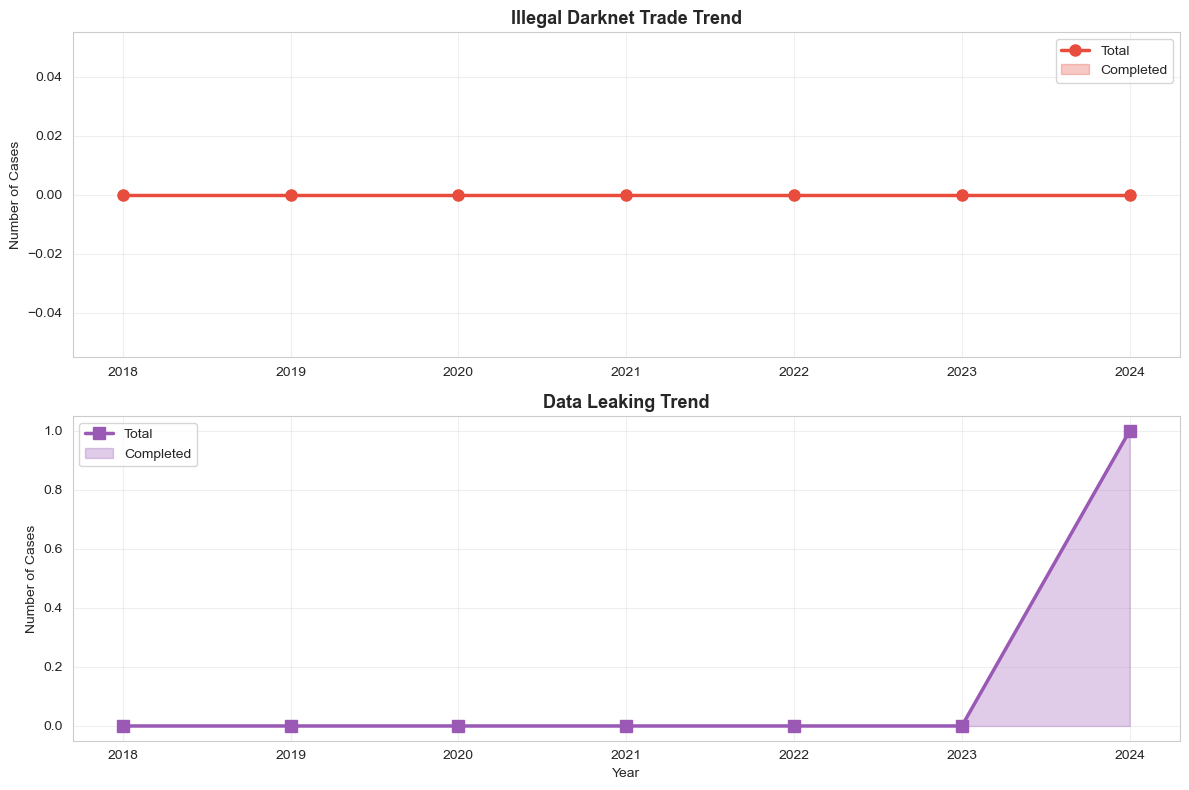

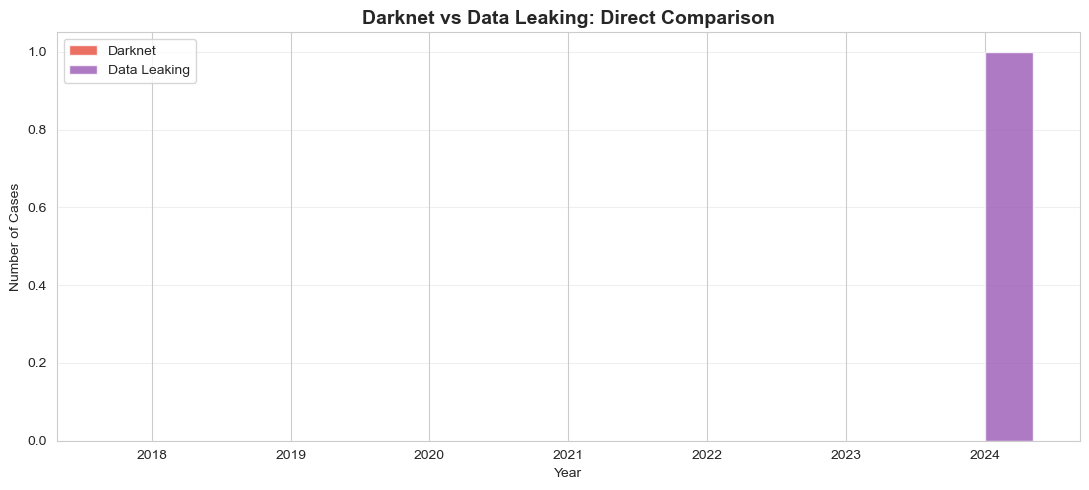

In [41]:
# Visualize Darknet vs Data Leaking trends
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Darknet trend
axes[0].plot(threats_df.index, threats_df['Darknet_Total'], marker='o', linewidth=2.5, markersize=8, color='#e74c3c', label='Total')
axes[0].fill_between(threats_df.index, threats_df['Darknet_Completed'], alpha=0.3, color='#e74c3c', label='Completed')
axes[0].set_title('Illegal Darknet Trade Trend', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Cases')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Data Leaking trend
axes[1].plot(threats_df.index, threats_df['Data_Leaking_Total'], marker='s', linewidth=2.5, markersize=8, color='#9b59b6', label='Total')
axes[1].fill_between(threats_df.index, threats_df['Data_Leaking_Completed'], alpha=0.3, color='#9b59b6', label='Completed')
axes[1].set_title('Data Leaking Trend', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Cases')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Side-by-side comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(threats_df.index))
width = 0.35

ax.bar(x - width/2, threats_df['Darknet_Total'], width, label='Darknet', color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, threats_df['Data_Leaking_Total'], width, label='Data Leaking', color='#9b59b6', alpha=0.8)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Cases')
ax.set_title('Darknet vs Data Leaking: Direct Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(threats_df.index)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [42]:
# Basic data exploration
print("Dataset Info:")
print(f"Total rows: {len(df)}")
print(f"Years covered: {sorted(df['Year'].unique())}")
print(f"\nNumber of crime categories (high-level): {df['Crime_Category'].nunique()}")
print(f"Number of crime types (detailed): {df['Crime_Type'].nunique()}")

print("\nCrime Categories:")
print(df['Crime_Category'].unique())

Dataset Info:
Total rows: 93
Years covered: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Number of crime categories (high-level): 5
Number of crime types (detailed): 12

Crime Categories:
<ArrowStringArray>
[        'Cybercrime (Narrow Sense)',        'Digitalized Property Crime',
             'Cyber-Sexual Offenses', 'Cyber-Defamation & Unfair Conduct',
              'Darknet/Data Leaking']
Length: 5, dtype: str


In [43]:
print("\nDetailed Crime Types:")
for category in df['Crime_Category'].unique():
    subtypes = df[df['Crime_Category'] == category]['Crime_Type'].unique()
    print(f"\n{category}:")
    for subtype in subtypes:
        print(f"  - {subtype}")


Detailed Crime Types:

Cybercrime (Narrow Sense):
  - Phishing
  - Hacking
  - Malware
  - DoS/DDoS

Digitalized Property Crime:
  - Cyberbetrug (Fraud)
  - Financial & Parcel Agents
  - Sextortion (Money)
  - Diebstahl Kryptowährungen

Cyber-Sexual Offenses:
  - Sexual Offenses

Cyber-Defamation & Unfair Conduct:
  - Defamation & Unfair Conduct

Darknet/Data Leaking:
  - Illegaler Handel im Darknet
  - Data leaking


In [44]:
# Statistical summary
print("\nStatistical Summary:")
print(df[['Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses', 'Crime_Rate']].describe())


Statistical Summary:
       Total_Offenses  Completed_Offenses  Attempted_Offenses  Crime_Rate
count       93.000000           93.000000           93.000000   93.000000
mean       579.172043          534.236559           44.935484    0.372043
std       1492.779983         1409.808293           94.383446    0.941133
min          0.000000            0.000000            0.000000    0.000000
25%         17.000000           15.000000            1.000000    0.000000
50%        115.000000           93.000000           11.000000    0.100000
75%        410.000000          331.000000           31.000000    0.300000
max      10692.000000        10213.000000          479.000000    6.700000



Total Crimes by Year:
Year
2017     2166
2018     3580
2019     4201
2020     5673
2021     6898
2022     7465
2023     9718
2024    14162
Name: Total_Offenses, dtype: int64


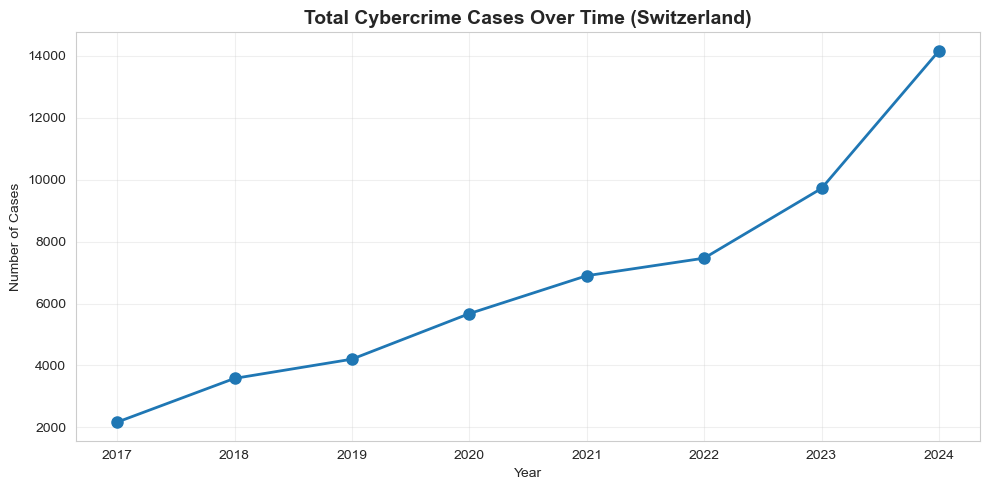

In [45]:
# Total crimes by year
crimes_by_year = df.groupby('Year')['Total_Offenses'].sum().sort_index()

print("\nTotal Crimes by Year:")
print(crimes_by_year)

# Plot trend
plt.figure(figsize=(10, 5))
plt.plot(crimes_by_year.index, crimes_by_year.values, marker='o', linewidth=2, markersize=8)
plt.title('Total Cybercrime Cases Over Time (Switzerland)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Completed vs Attempted Crimes by Year:
      Completed_Offenses  Attempted_Offenses
Year                                        
2017                1897                 269
2018                3088                 492
2019                3758                 443
2020                5154                 519
2021                6264                 634
2022                6890                 575
2023                9163                 555
2024               13470                 692


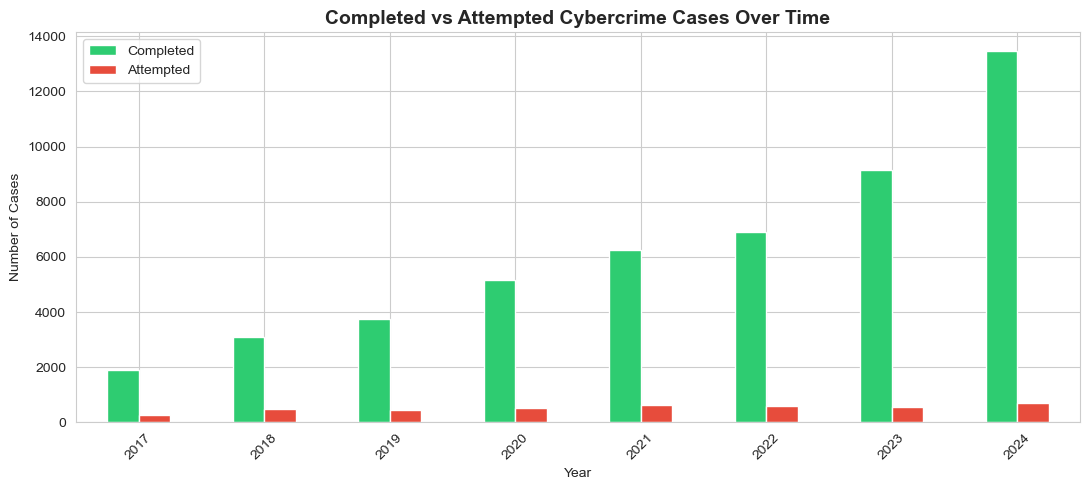

In [46]:
# Completed vs Attempted crimes
completion_by_year = df.groupby('Year')[['Completed_Offenses', 'Attempted_Offenses']].sum()

print("\nCompleted vs Attempted Crimes by Year:")
print(completion_by_year)

# Visualization
fig, ax = plt.subplots(figsize=(11, 5))
completion_by_year.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
plt.title('Completed vs Attempted Cybercrime Cases Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.legend(['Completed', 'Attempted'], loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Total Crimes by High-Level Category:
Crime_Category
Digitalized Property Crime           42368
Cybercrime (Narrow Sense)             6861
Cyber-Sexual Offenses                 3939
Cyber-Defamation & Unfair Conduct      694
Darknet/Data Leaking                     1
Name: Total_Offenses, dtype: int64


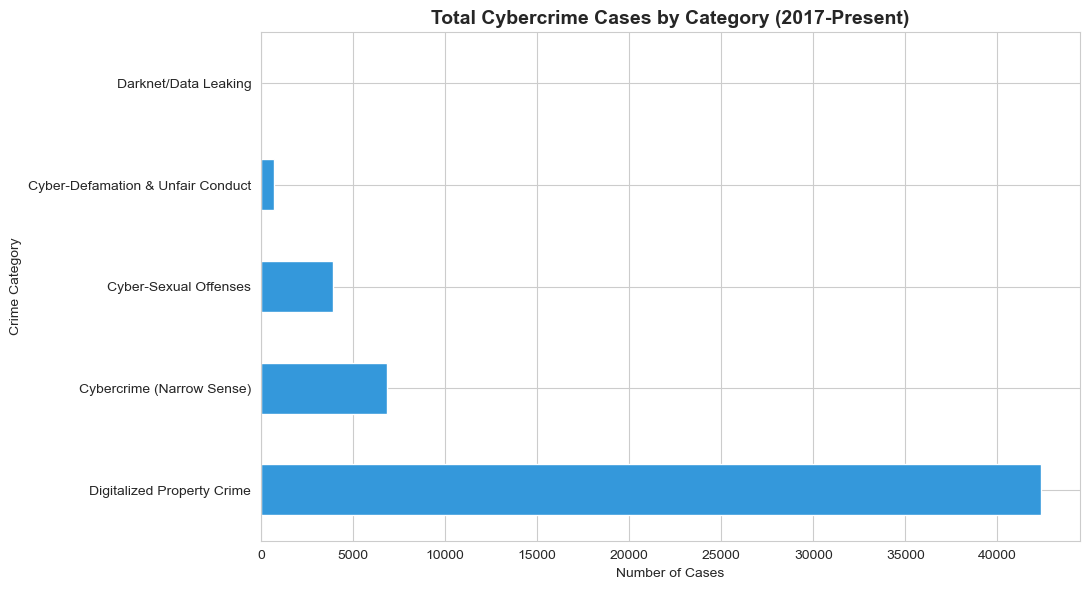

In [47]:
# Top crime categories overall
category_totals = df.groupby('Crime_Category')['Total_Offenses'].sum().sort_values(ascending=False)

print("\nTotal Crimes by High-Level Category:")
print(category_totals)

# Visualization
plt.figure(figsize=(11, 6))
category_totals.plot(kind='barh', color='#3498db')
plt.title('Total Cybercrime Cases by Category (2017-Present)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cases')
plt.ylabel('Crime Category')
plt.tight_layout()
plt.show()


Total Crimes by Detailed Type:
Crime_Type
Cyberbetrug (Fraud)            36126
Financial & Parcel Agents       4311
Sexual Offenses                 3939
Phishing                        3795
Hacking                         2077
Sextortion (Money)              1790
Malware                          880
Defamation & Unfair Conduct      694
Diebstahl Kryptowährungen        141
DoS/DDoS                         109
Data leaking                       1
Illegaler Handel im Darknet        0
Name: Total_Offenses, dtype: int64


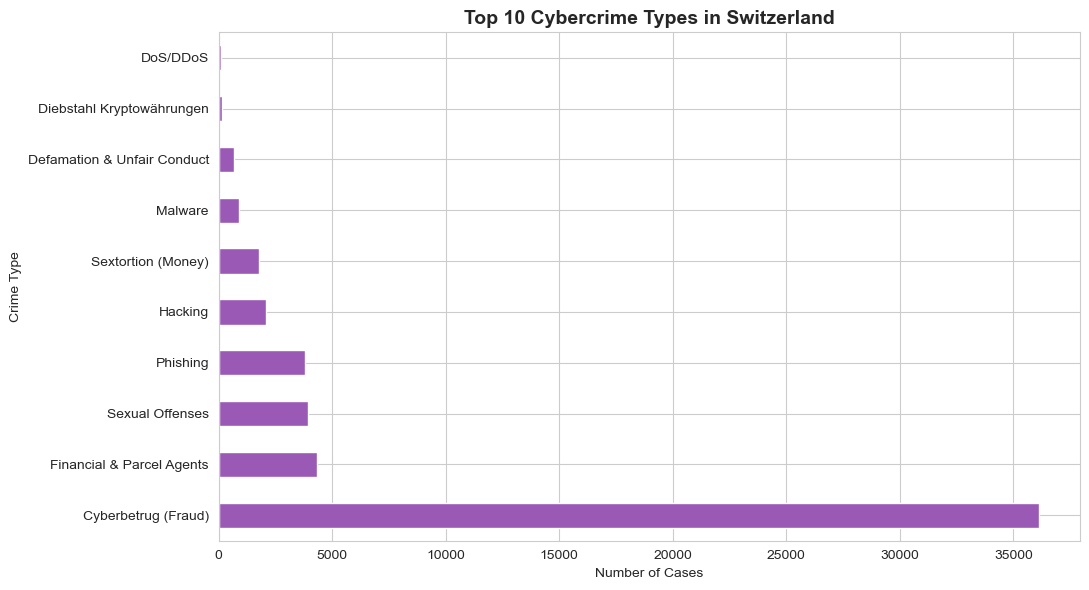

In [48]:
# Top crime types (subcategories)
subtype_totals = df.groupby('Crime_Type')['Total_Offenses'].sum().sort_values(ascending=False)

print("\nTotal Crimes by Detailed Type:")
print(subtype_totals)

# Visualization - top 10
plt.figure(figsize=(11, 6))
subtype_totals.head(10).plot(kind='barh', color='#9b59b6')
plt.title('Top 10 Cybercrime Types in Switzerland', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cases')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()


Category Trends Over Time:
Crime_Category  Cyber-Defamation & Unfair Conduct  Cyber-Sexual Offenses  \
Year                                                                       
2017                                         76.0                  120.0   
2018                                         82.0                  148.0   
2019                                        115.0                  587.0   
2020                                         91.0                  587.0   
2021                                         94.0                  578.0   
2022                                         93.0                  697.0   
2023                                         69.0                  573.0   
2024                                         74.0                  649.0   

Crime_Category  Cybercrime (Narrow Sense)  Darknet/Data Leaking  \
Year                                                              
2017                                590.0                   NaN   
2018      

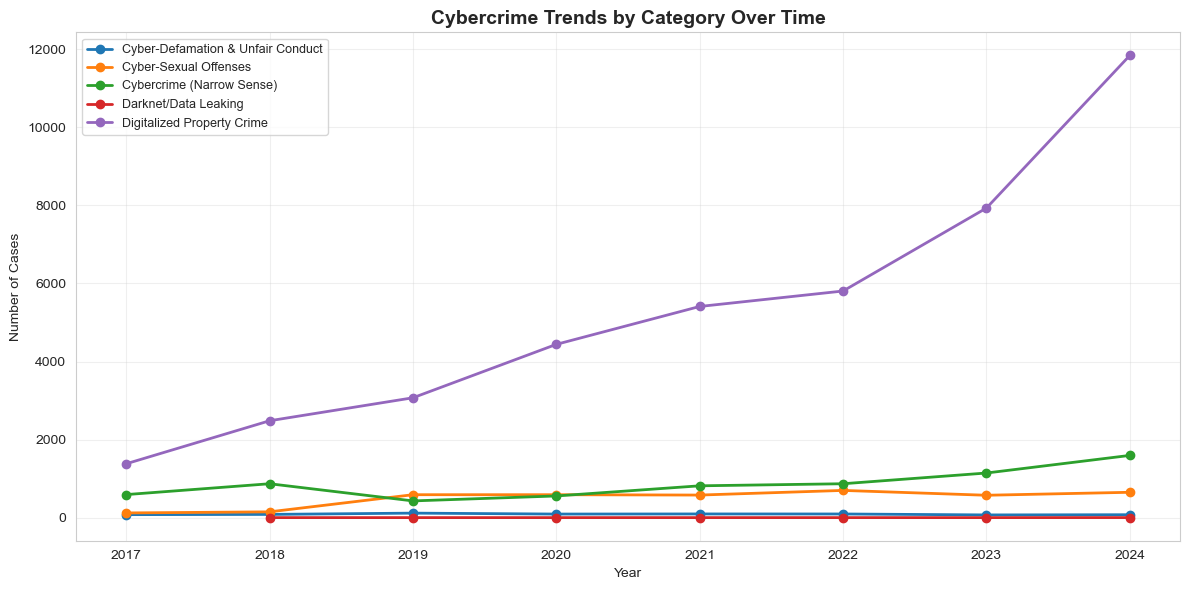

In [49]:
# Trend analysis for each category
category_trends = df.pivot_table(values='Total_Offenses', index='Year', columns='Crime_Category', aggfunc='sum')

print("\nCategory Trends Over Time:")
print(category_trends)

# Visualization
plt.figure(figsize=(12, 6))
for column in category_trends.columns:
    plt.plot(category_trends.index, category_trends[column], marker='o', label=column, linewidth=2)

plt.title('Cybercrime Trends by Category Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Average Crime Rate (per 100,000 inhabitants) by Year:
Year
2017    0.166667
2018    0.208333
2019    0.241667
2020    0.308333
2021    0.366667
2022    0.391667
2023    0.508333
2024    0.733333
Name: Crime_Rate, dtype: float64


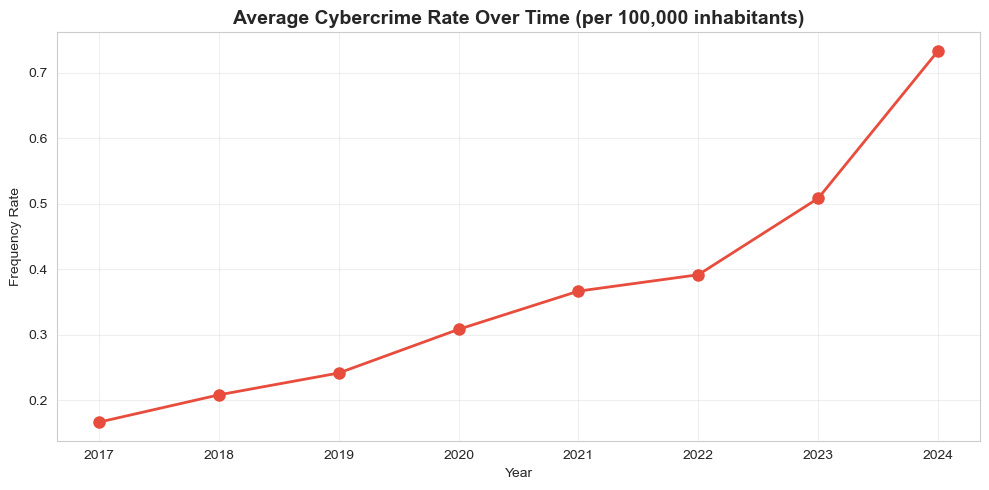

In [50]:
# Crime rate (Häufigkeitszahl) analysis
crime_rate_by_year = df.groupby('Year')['Crime_Rate'].mean()

print("\nAverage Crime Rate (per 100,000 inhabitants) by Year:")
print(crime_rate_by_year)

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(crime_rate_by_year.index, crime_rate_by_year.values, marker='o', color='#e74c3c', linewidth=2, markersize=8)
plt.title('Average Cybercrime Rate Over Time (per 100,000 inhabitants)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Frequency Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
# Success rate (completion percentage) by crime type
latest_year = df['Year'].max()
latest_data = df[df['Year'] == latest_year].copy()
latest_data['Completion_Rate'] = (latest_data['Completed_Offenses'] / latest_data['Total_Offenses'] * 100).round(2)

completion_by_type = latest_data.groupby('Crime_Type')[['Total_Offenses', 'Completed_Offenses', 'Completion_Rate']].sum()
completion_by_type['Completion_Rate'] = (completion_by_type['Completed_Offenses'] / completion_by_type['Total_Offenses'] * 100).round(2)
completion_by_type = completion_by_type.sort_values('Completion_Rate', ascending=False)

print(f"\nCompletion Rates by Crime Type ({latest_year}):")
print(completion_by_type)


Completion Rates by Crime Type (2024):
                             Total_Offenses  Completed_Offenses  \
Crime_Type                                                        
Data leaking                              1                   1   
Diebstahl Kryptowährungen                27                  27   
Sexual Offenses                         649                 639   
Phishing                               1109                1078   
Hacking                                 329                 316   
Defamation & Unfair Conduct              74                  71   
Cyberbetrug (Fraud)                   10692               10213   
Financial & Parcel Agents               757                 722   
DoS/DDoS                                 12                  10   
Malware                                 144                 120   
Sextortion (Money)                      368                 273   
Illegaler Handel im Darknet               0                   0   

                     

<Figure size 1200x600 with 0 Axes>

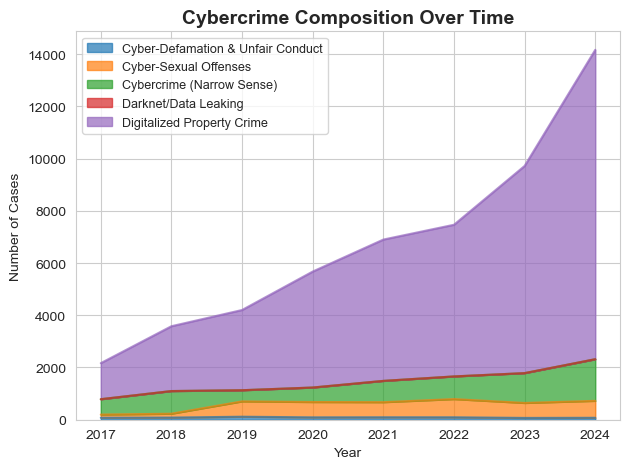

In [52]:
# Stacked area chart for category composition over time
category_composition = df.pivot_table(values='Total_Offenses', index='Year', columns='Crime_Category', aggfunc='sum')

plt.figure(figsize=(12, 6))
category_composition.plot(kind='area', stacked=True, alpha=0.7)
plt.title('Cybercrime Composition Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Summary of Interesting Visualization Ideas

Based on the data analysis above, here are **compelling visualizations** for displaying the Swiss cybercrime situation:

### 1. **Time Series Line Chart (Overall Trend)**
- Show total cybercrime cases over years
- Simple, clear trend showing growth or decline
- Good for the main homepage/landing page

### 2. **Category Breakdown (Horizontal Bar Chart)**
- Display the 4-5 main crime categories with total cases
- Color-coded by category type
- Shows which categories are most prevalent

### 3. **Multi-Line Trend Analysis**
- Show how each major crime category trends over time
- Reveals which types are increasing/decreasing
- Good for understanding shifts in cybercrime patterns

### 4. **Stacked Area Chart**
- Shows both total volume AND category composition changes
- Visually shows how the cybercrime landscape is evolving
- Useful for understanding market share of each crime type

### 5. **Completed vs Attempted Comparison**
- Stacked or grouped bar chart by year
- Shows success rate and deterrence effectiveness
- Indicates which years had more attempted vs completed crimes

### 6. **Crime Type Ranking (Top 10)**
- Horizontal bar chart of the most common specific crime types
- Examples: Cyberbetrug (fraud), Phishing, Hacking, etc.
- Helps identify the most pressing threats

### 7. **Crime Rate Heatmap**
- Matrix showing category × year with color intensity
- Easy to spot trends and peaks
- Good for detailed exploration

### 8. **Interactive Dashboard (Future)**
- Combine multiple views (filters, drill-downs)
- Allow users to explore by category, year, crime type
- Show completion rates and frequency statistics